In [1]:
!pip install stockwell

Defaulting to user installation because normal site-packages is not writeable
Looking in indexes: https://pypi.org/simple, https://pypi.ngc.nvidia.com

[notice] A new release of pip is available: 24.2 -> 25.2
[notice] To update, run: python -m pip install --upgrade pip


In [2]:
import numpy as np
from scipy.signal import chirp
import matplotlib.pyplot as plt
from stockwell import st
import pandas as pd

In [3]:
import random

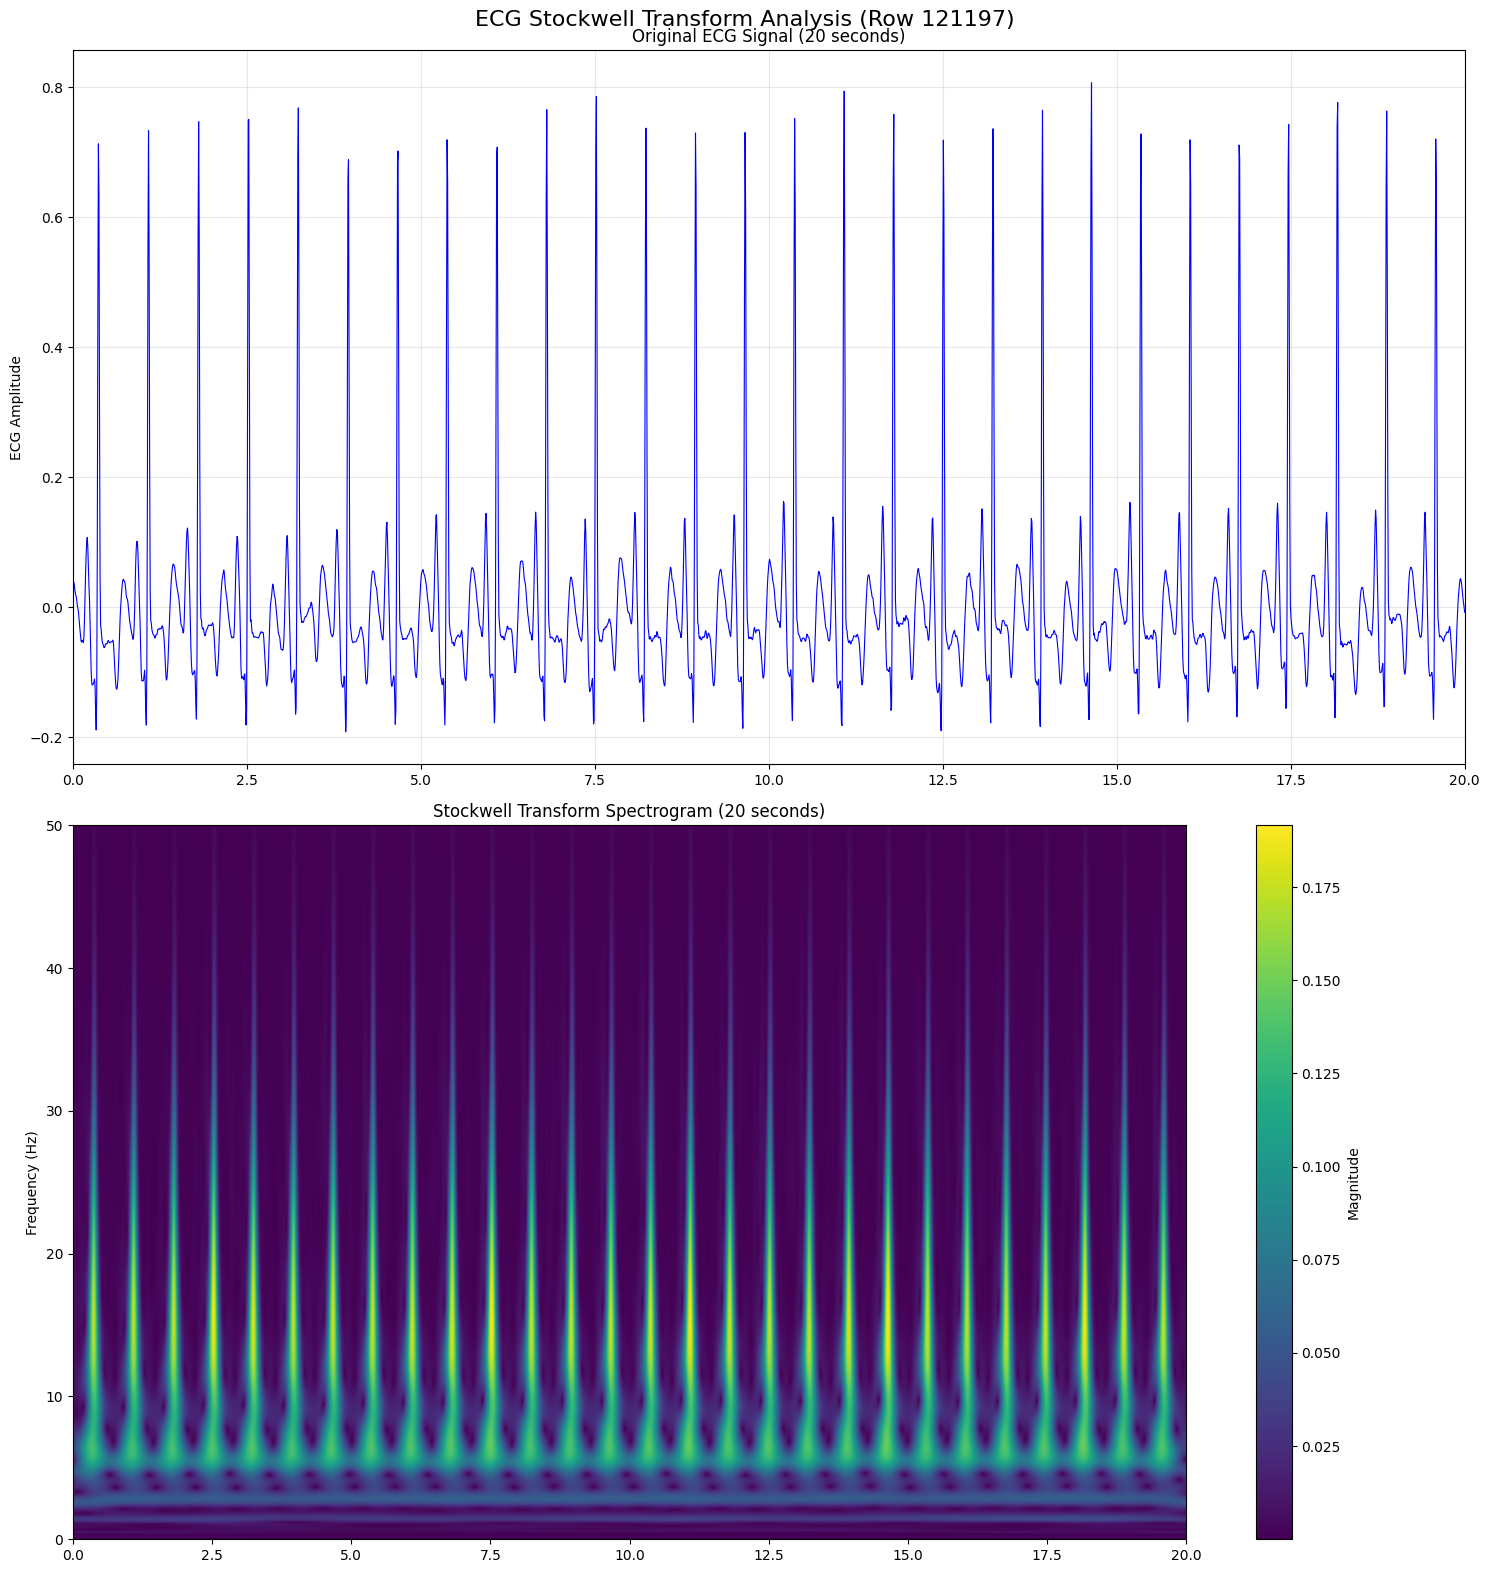

In [ ]:
data = pd.read_pickle('20s_sample.pkl')
random_idx = random.randint(0, len(data)-1)
ecg_signal = np.array(data.iloc[random_idx]['ecg'])

fs = 125  # fs
duration = 20  # sec
t = np.linspace(0, duration, len(ecg_signal))
fmin = 0   # min freq (ST segment..)
fmax = 50    # Max freq (QRS complex..)
df = 1./(t[-1]-t[0])                    # 주파수 해상도
fmin_samples = int(fmin/df)
fmax_samples = int(fmax/df)
stock = st.st(ecg_signal, fmin_samples, fmax_samples)


extent_20sec = (t[0], t[-1], fmin, fmax)
time_5sec = t <= 5
extent_5sec = (0, 5, fmin, fmax)

fig, ax = plt.subplots(2, 1, figsize=(15, 16))
fig.suptitle(f'ECG Stockwell Transform Analysis (Row {random_idx})', fontsize=16)

# 7-1. Orig ECG (20sec)
ax[0].plot(t, ecg_signal, 'b-', linewidth=0.8)
ax[0].set_ylabel('ECG Amplitude')
ax[0].set_title('Original ECG Signal (20 seconds)')
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(0, 20)

# 20sec S-transform
im1 = ax[1].imshow(np.abs(stock), origin='lower', extent=extent_20sec, aspect='auto', cmap='viridis')
ax[1].set_ylabel('Frequency (Hz)')
ax[1].set_title('Stockwell Transform Spectrogram (20 seconds)')

plt.colorbar(im1, ax=ax[1], label='Magnitude')
plt.tight_layout()
plt.show()

In [ ]:
# Inverse Transformation and Restoration Verification
print("\n🔄 역변환 수행 중...")
inv_stock = st.ist(stock, fmin_samples, fmax_samples)

# 복원 오차 계산
reconstruction_error = np.mean(np.abs(ecg_signal - inv_stock))
max_error = np.max(np.abs(ecg_signal - inv_stock))

print(f"평균 복원 오차: {reconstruction_error:.6f}")
print(f"최대 복원 오차: {max_error:.6f}")


🔄 역변환 수행 중...
평균 복원 오차: 0.000036
최대 복원 오차: 0.004920


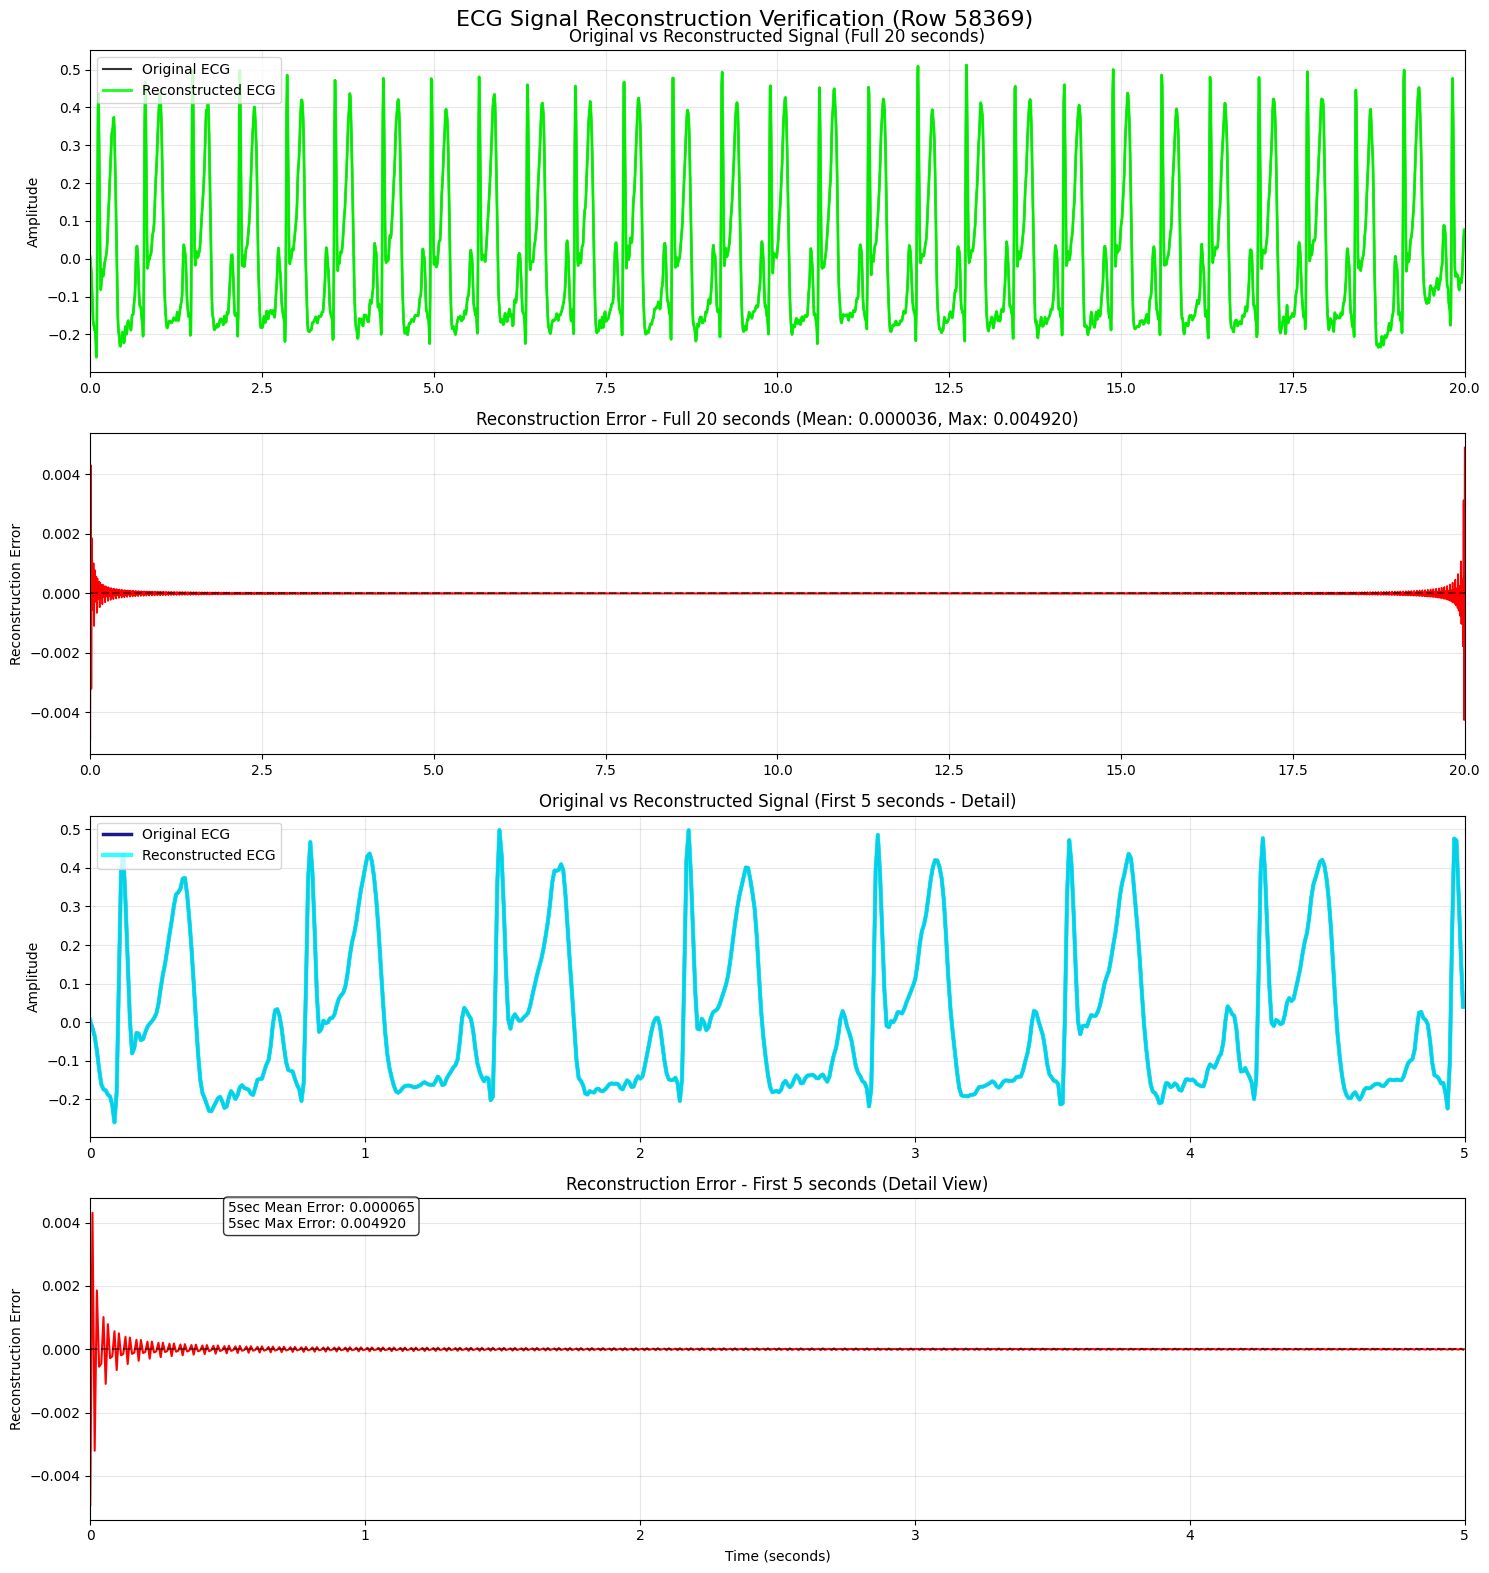

In [ ]:
fig, ax = plt.subplots(4, 1, figsize=(15, 16))
fig.suptitle(f'ECG Signal Reconstruction Verification (Row {random_idx})', fontsize=16)

# Comparison of the 20-second signal 
ax[0].plot(t, ecg_signal, 'k-', label='Original ECG', linewidth=1.5, alpha=0.8)  
ax[0].plot(t, inv_stock, color='lime', linestyle='-', label='Reconstructed ECG', linewidth=2, alpha=0.9)  
ax[0].set_ylabel('Amplitude')
ax[0].set_title('Original vs Reconstructed Signal (Full 20 seconds)')
ax[0].legend()
ax[0].grid(True, alpha=0.3)
ax[0].set_xlim(0, 20)

# 20-second restoration error
difference_20sec = ecg_signal - inv_stock
ax[1].plot(t, difference_20sec, 'red', linewidth=1.2)
ax[1].set_ylabel('Reconstruction Error')
ax[1].set_title(f'Reconstruction Error - Full 20 seconds (Mean: {reconstruction_error:.6f}, Max: {max_error:.6f})')
ax[1].grid(True, alpha=0.3)
ax[1].set_xlim(0, 20)
ax[1].axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Comparison of the 5-second signal 
ax[2].plot(t[time_5sec], ecg_signal[time_5sec], 'navy', label='Original ECG', linewidth=2.5, alpha=0.9)  
ax[2].plot(t[time_5sec], inv_stock[time_5sec], color='cyan', linestyle='-', label='Reconstructed ECG', linewidth=3, alpha=0.8)  
ax[2].set_ylabel('Amplitude')
ax[2].set_title('Original vs Reconstructed Signal (First 5 seconds - Detail)')
ax[2].legend()
ax[2].grid(True, alpha=0.3)
ax[2].set_xlim(0, 5)

# 5-second restoration error
difference_5sec = difference_20sec[time_5sec]
ax[3].plot(t[time_5sec], difference_5sec, 'red', linewidth=1.5)
ax[3].set_xlabel('Time (seconds)')
ax[3].set_ylabel('Reconstruction Error')
ax[3].set_title('Reconstruction Error - First 5 seconds (Detail View)')
ax[3].grid(True, alpha=0.3)
ax[3].set_xlim(0, 5)
ax[3].axhline(y=0, color='black', linestyle='--', alpha=0.5)

# Statistics on errors in 5-second intervals
error_5sec_mean = np.mean(np.abs(difference_5sec))
error_5sec_max = np.max(np.abs(difference_5sec))
ax[3].text(0.5, ax[3].get_ylim()[1]*0.8, 
           f'5sec Mean Error: {error_5sec_mean:.6f}\n5sec Max Error: {error_5sec_max:.6f}', 
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()